# 02b · What narrowing the channel does to the network

*Companion to task 02. No new fits: every panel reads the 175 grid runs and the ten dense
fits from task 01.*

Task 02 established what the bottleneck costs in fit and that within-region rank is free
while cross-region rank is not. This notebook asks what the constrained networks are
*doing* differently — where a region's drive comes from, how many dimensions the drive and
the state occupy, how the flow between regions is arranged in time, and whether any of that
differs between fixation types.

**Three reference cells** carry most of the time-resolved figures:

| cell | $r_w$ | $r_c$ | worst cell | role |
|---|---|---|---|---|
| `full` | dense | dense | 0.991 | the unconstrained network (task 01, ten seeds) |
| `w1_c10` | 1 | 10 | 0.983 | the tightest adequate cell — task 02's selection |
| `w1_c1` | 1 | 1 | 0.938 | the tightest cell fitted, well below the bar |

Everything scalar is shown along both marginals, so the effect of each constraint can be read
with the other side dense.

**Two rules carried from the audit.** Raw current magnitudes are not comparable across cells
(a rank-constrained model compensates with larger weights everywhere) or across fixation
types (interactive face has half the target variance), so every cross-cell and
cross-condition claim here rests on **shares, fractions, cosines and participation ratios**.
And a property that changes with rank is only interesting if it is not simply the target
showing through, so the state-level quantities are read against what task 07 established
the target itself carries.

| Section | |
|---|---|
| 1 | Fit per fixation type along each marginal |
| 2 | Where a region's drive comes from |
| 3 | Drive rank against state rank — how the nonlinearity re-expands a narrow channel |
| 4 | What the state does: speed and extent |
| 5 | Flow between regions over time |
| 6 | Steady or bursty: the network's share of drive within a trial |
| 7 | With or against: incoming current and a region's own dynamics, in time |
| 8 | Reading the result |

In [1]:
%load_ext autoreload
%autoreload 2

from __future__ import annotations

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import yaml
from IPython.display import Image, Markdown, display

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_audit as audit
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_sweep as sweep
from dal_monte_2022_analysis.ephys.analysis import fixation_mrnn_synthesis as syn
from dal_monte_2022_analysis.ephys.plotting import fixation_mrnn_audit as aviz
from dal_monte_2022_analysis.ephys.plotting.thesis_common import (
    ThesisFigureSettings, apply_thesis_plot_style, figure_to_png_bytes, save_thesis_figure,
)

DATASET_CFG_PATH = repo_root / "configs" / "dataset.yaml"
apply_thesis_plot_style(load_config(repo_root / "configs" / "plotting.yaml"))

TREE = "final"
LADDER_ROOT = sweep.resolve_task_root("01_ladder", DATASET_CFG_PATH, tree=TREE)
GRID_ROOT = sweep.resolve_task_root("02_rank_grid", DATASET_CFG_PATH, tree=TREE)
TASK_ROOT = sweep.resolve_task_root("02b_bottleneck_properties", DATASET_CFG_PATH, tree=TREE)
FIGURE_DIR = syn.resolve_output_dir(DATASET_CFG_PATH, scope="final_02b_bottleneck_properties")
FIGURES = ThesisFigureSettings(output_dir=FIGURE_DIR)

BASE = yaml.safe_load((TASK_ROOT.parent / "base_model.yaml").read_text())
HIDDEN_UNITS = int(BASE["hidden_units"])
RANKS = (1, 2, 3, 5, 10)
ADEQUATE_BAR = 0.98
SELECTED = yaml.safe_load((GRID_ROOT / "selected_bottleneck.yaml").read_text())
REFERENCE_CELLS = ["full", SELECTED["label"], "w1_c1"]

#: Every grid cell plus the dense corner, labelled so annotate_rank_grid can read the ranks.
ARMS = {"full": LADDER_ROOT / "full"}
ARMS.update({v.label: GRID_ROOT / v.label
             for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)})
ARMS = {k: p for k, p in ARMS.items() if audit.seed_run_dirs(p)}


def show(figure, stem: str) -> None:
    save_thesis_figure(figure, FIGURES, stem)
    display(Image(data=figure_to_png_bytes(figure, dpi=190)))


def cached(name: str, build):
    path = TASK_ROOT / "tables" / f"{name}.csv"
    if path.exists():
        return pd.read_csv(path)
    frame = build()
    path.parent.mkdir(parents=True, exist_ok=True)
    frame.to_csv(path, index=False)
    return frame


def with_ranks(frame: pd.DataFrame) -> pd.DataFrame:
    return audit.annotate_rank_grid(frame, hidden_units=HIDDEN_UNITS)


print(f"{len(ARMS)} cells; reference cells {REFERENCE_CELLS}")

36 cells; reference cells ['full', 'w1_c10', 'w1_c1']


## 1. Fit per fixation type along each marginal

Under the minimax objective the three fixation types are pushed toward the same fit, so any
gap that remains is one the optimiser could not close. Left: cross-region rank with
within-region dense. Right: the reverse. Dotted lines are the dense network.

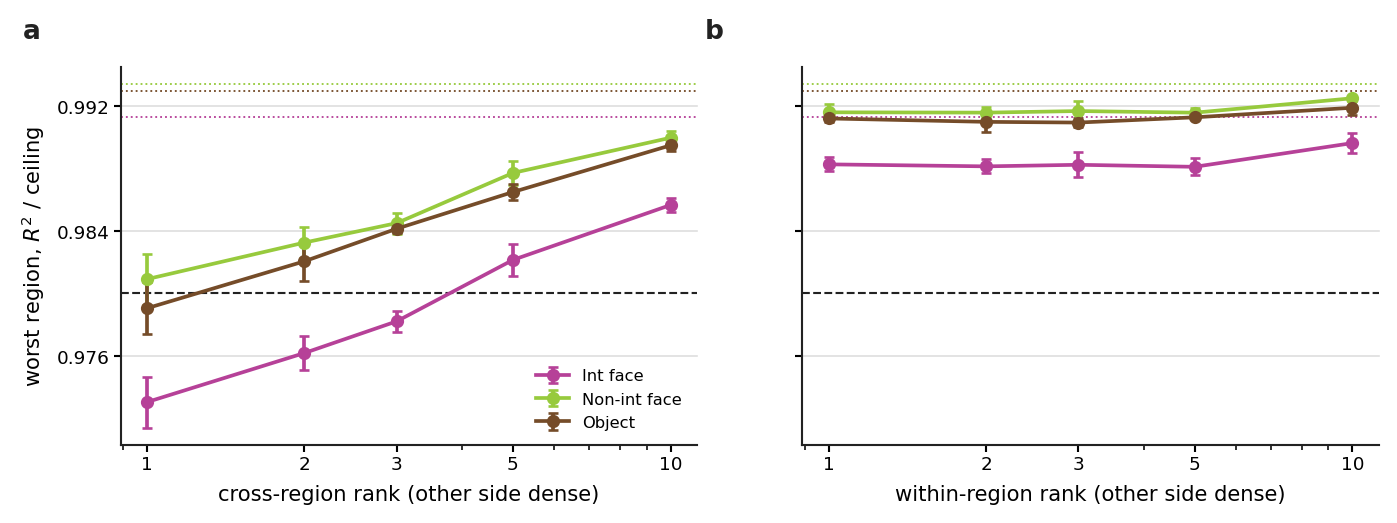

**Interactive face is the worst-fitted condition in this many (cell, seed, region) fits, by cross rank:**

,interactive face worst
rank_cross,
1,120/120
2,120/120
3,120/120
5,120/120
10,119/120
40,83/100


condition,face_interactive,face_non_interactive,object,int − non-int
rank_cross,,,,
1,0.9769,0.9858,0.9821,-0.0089
2,0.9802,0.9885,0.9851,-0.0083
3,0.9824,0.9904,0.9868,-0.0080
5,0.9861,0.9933,0.9894,-0.0072
10,0.9902,0.9964,0.9926,-0.0062


In [2]:
fit = with_ranks(pd.read_csv(GRID_ROOT / "tables" / "grid_fit.csv"))
full_fit = pd.read_csv(LADDER_ROOT / "tables" / "ladder_fit_matched.csv")
full_fit = full_fit[full_fit["label"] == "full"]
dense_by_condition = full_fit.groupby(["seed", "condition"])["r2_vs_ceiling"].min().groupby("condition").mean().to_dict()

show(aviz.plot_condition_fit_vs_rank(fit, dense_by_condition=dense_by_condition, bar=ADEQUATE_BAR),
     "fig01_condition_fit_vs_rank")
worst = fit.groupby(["label", "rank_within", "rank_cross", "seed", "region", "condition"])["r2_vs_ceiling"].mean().unstack("condition")
by_cross = worst.groupby(level="rank_cross").apply(lambda d: f"{int((d.idxmin(axis=1) == 'face_interactive').sum())}/{len(d)}")
display(Markdown("**Interactive face is the worst-fitted condition in this many (cell, seed, region) fits, by cross rank:**"))
display(by_cross.to_frame("interactive face worst"))
gap = fit[fit["rank_within"] == HIDDEN_UNITS].groupby(["rank_cross", "condition"])["r2_vs_ceiling"].mean().unstack()
gap["int − non-int"] = gap["face_interactive"] - gap["face_non_interactive"]
display(gap.round(4))

## 2. Where a region's drive comes from

The fraction of a region's total recurrent drive energy that arrives from the other three
regions rather than from its own recurrent block, for every cell, per region and fixation
type. This is the quantity task 06's E2 correction was about: reported with the self-block
included it was uninterpretable, and here it is the whole point.

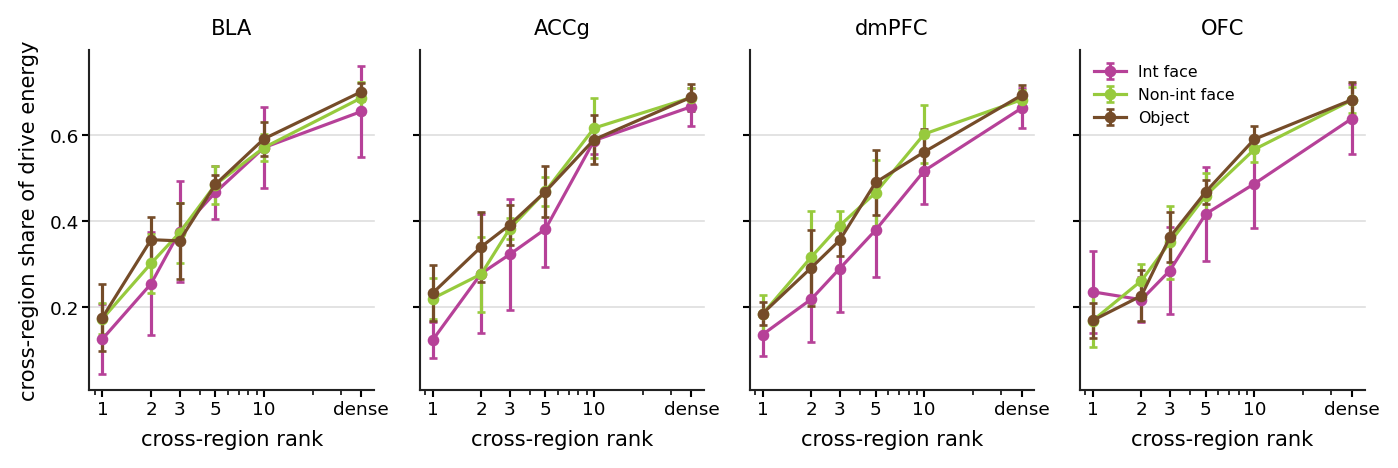

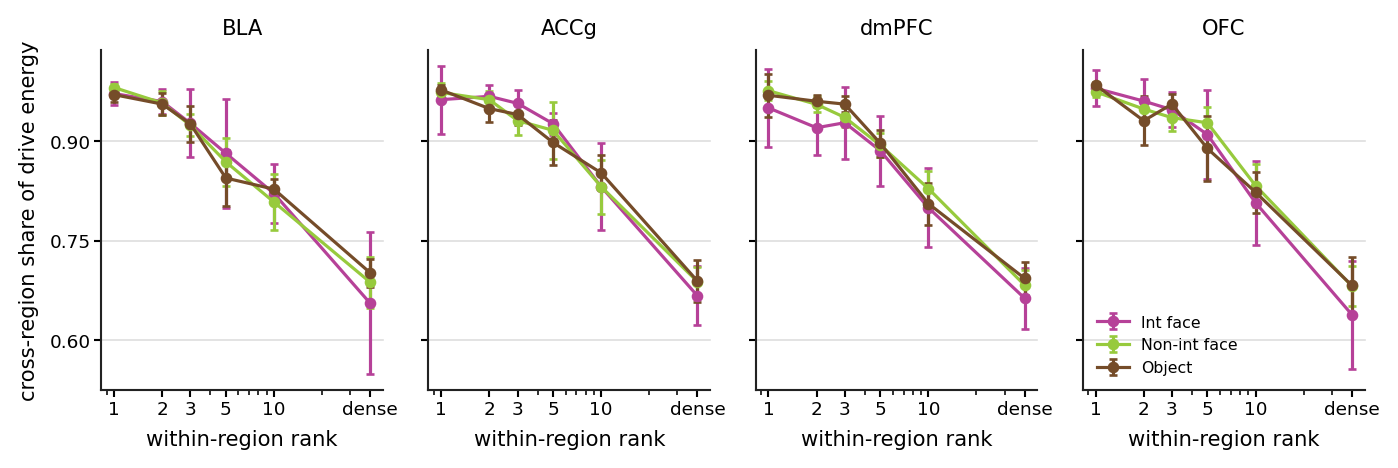

,cross share (mean)
label,
full,0.677
w1_c10,0.957
w1_c1,0.729


In [3]:
props = with_ranks(cached("region_state_properties",
                          lambda: audit.collect_over_arms(ARMS, audit.region_state_properties)))
cross_dense = props[props["rank_cross"] == HIDDEN_UNITS]
within_dense = props[props["rank_within"] == HIDDEN_UNITS]
show(aviz.plot_property_vs_rank(within_dense, "cross_energy_fraction", rank_column="rank_cross",
                                ylabel="cross-region share of drive energy"),
     "fig02a_cross_share_vs_cross_rank")
show(aviz.plot_property_vs_rank(cross_dense, "cross_energy_fraction", rank_column="rank_within",
                                ylabel="cross-region share of drive energy"),
     "fig02b_cross_share_vs_within_rank")
display(props.groupby("label")["cross_energy_fraction"].mean().loc[REFERENCE_CELLS].round(3).to_frame("cross share (mean)"))

Read the two panels together. Squeezing the **within-region** block to rank 1 with the
network dense pushes the cross share to ~0.95 — the region stops driving itself and lets the
network do it, and task 02 showed this costs nothing. Squeezing the **cross-region** channel
with self-recurrence dense does the mirror image: the cross share falls to ~0.17 and the self
block takes over the drive. So the network *can* reroute in either direction and does. The
asymmetry is in what the rerouted drive can achieve: driven by the network, a region
reproduces its data to the ceiling; driven by its own recurrence, it does not (task 02, cross
marginal). Self-recurrence is a substitute in energy but not in content.

Interactive face sits lowest at every constrained cross rank in most regions — under a narrow
channel it is the fixation type that falls back on self-recurrence most, and it is also the
worst-fitted. The fixation type that most needs the channel is the one a narrow channel serves
least.

## 3. Drive rank against state rank

The rank constraints bound the pre-activation: a region's drive lives in at most
$r_w + 3\,r_c$ dimensions. The readout needs roughly 39 linear dimensions of *state*. What
closes the gap is the tanh and the trained initial state, and the participation ratios show
how much re-expansion is being asked of them.

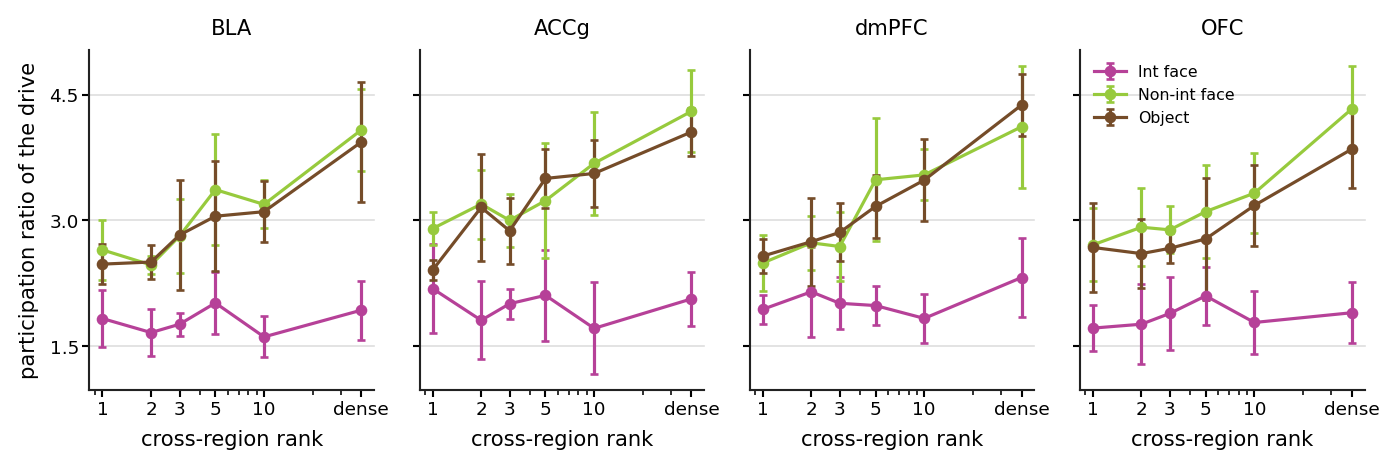

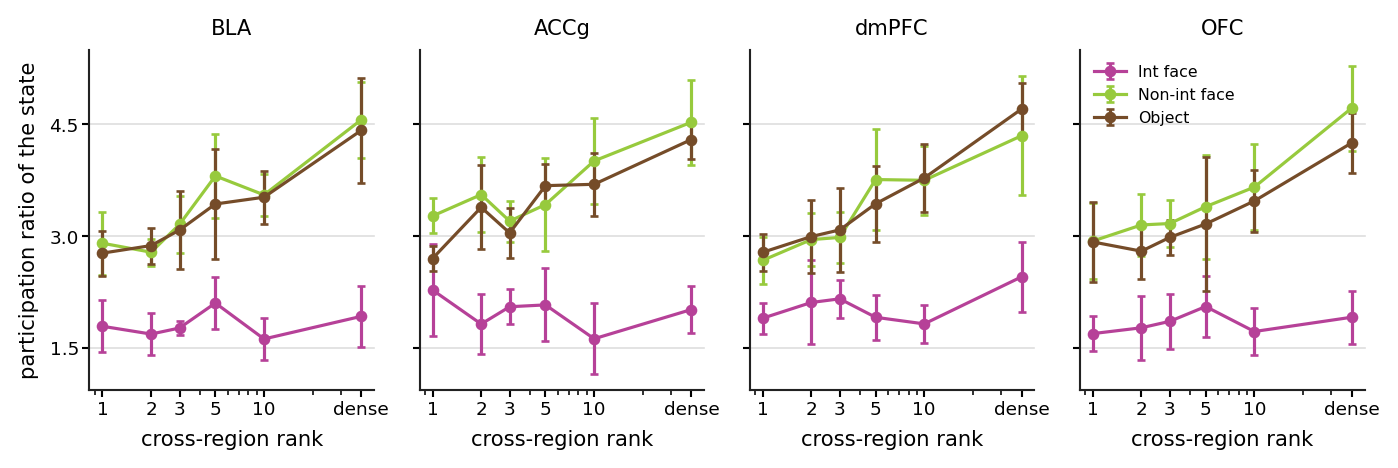

,drive_pr,self_pr,cross_pr,state_pr
label,,,,
full,3.44,3.26,3.55,3.67
w1_c10,2.65,1.00,2.65,2.88
w1_c1,1.75,1.00,1.71,1.94


In [4]:
for prop, label in (("drive_pr", "participation ratio of the drive"),
                    ("state_pr", "participation ratio of the state")):
    show(aviz.plot_property_vs_rank(within_dense, prop, rank_column="rank_cross", ylabel=label),
         f"fig03_{prop}_vs_cross_rank")
summary = props.groupby("label")[["drive_pr", "self_pr", "cross_pr", "state_pr"]].mean()
display(summary.loc[REFERENCE_CELLS].round(2))

## 4. What the state does

Speed and extent of the hidden trajectory per region and fixation type against cross-region
rank. Task 07 established that interactive face is smaller and slower *in the target*, so a
difference between fixation types here is expected; what is not given in advance is whether
the bottleneck changes them, and whether it does so differently per fixation type.

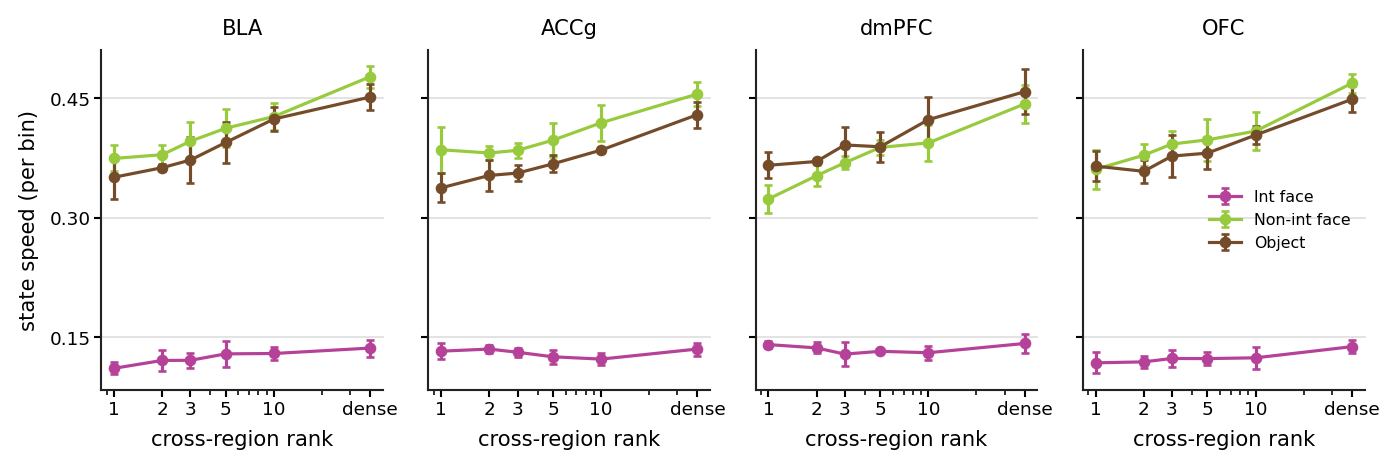

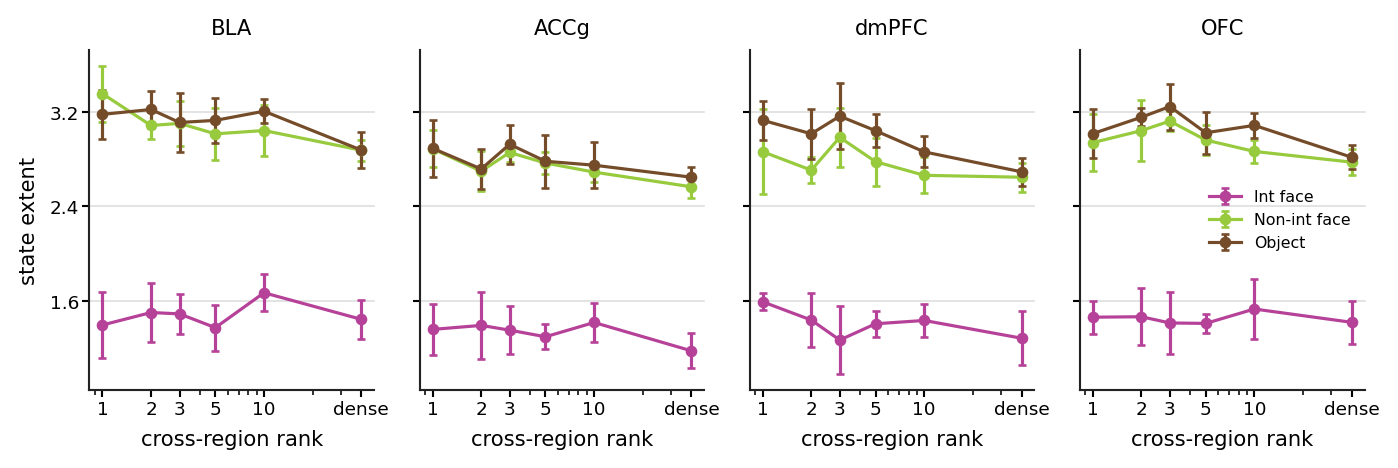

In [5]:
for prop, label in (("state_speed", "state speed (per bin)"), ("state_extent", "state extent")):
    show(aviz.plot_property_vs_rank(within_dense, prop, rank_column="rank_cross", ylabel=label),
         f"fig04_{prop}_vs_cross_rank")

## 5. Flow between regions over time

$|c_{s\to t}(\tau)|$ for every source into every target, seed-averaged. The diagonal is each
region's own recurrence. First as a share of the target's total drive energy at each time
step — the comparable quantity — then raw, to show what the constrained models actually do
to the magnitudes.

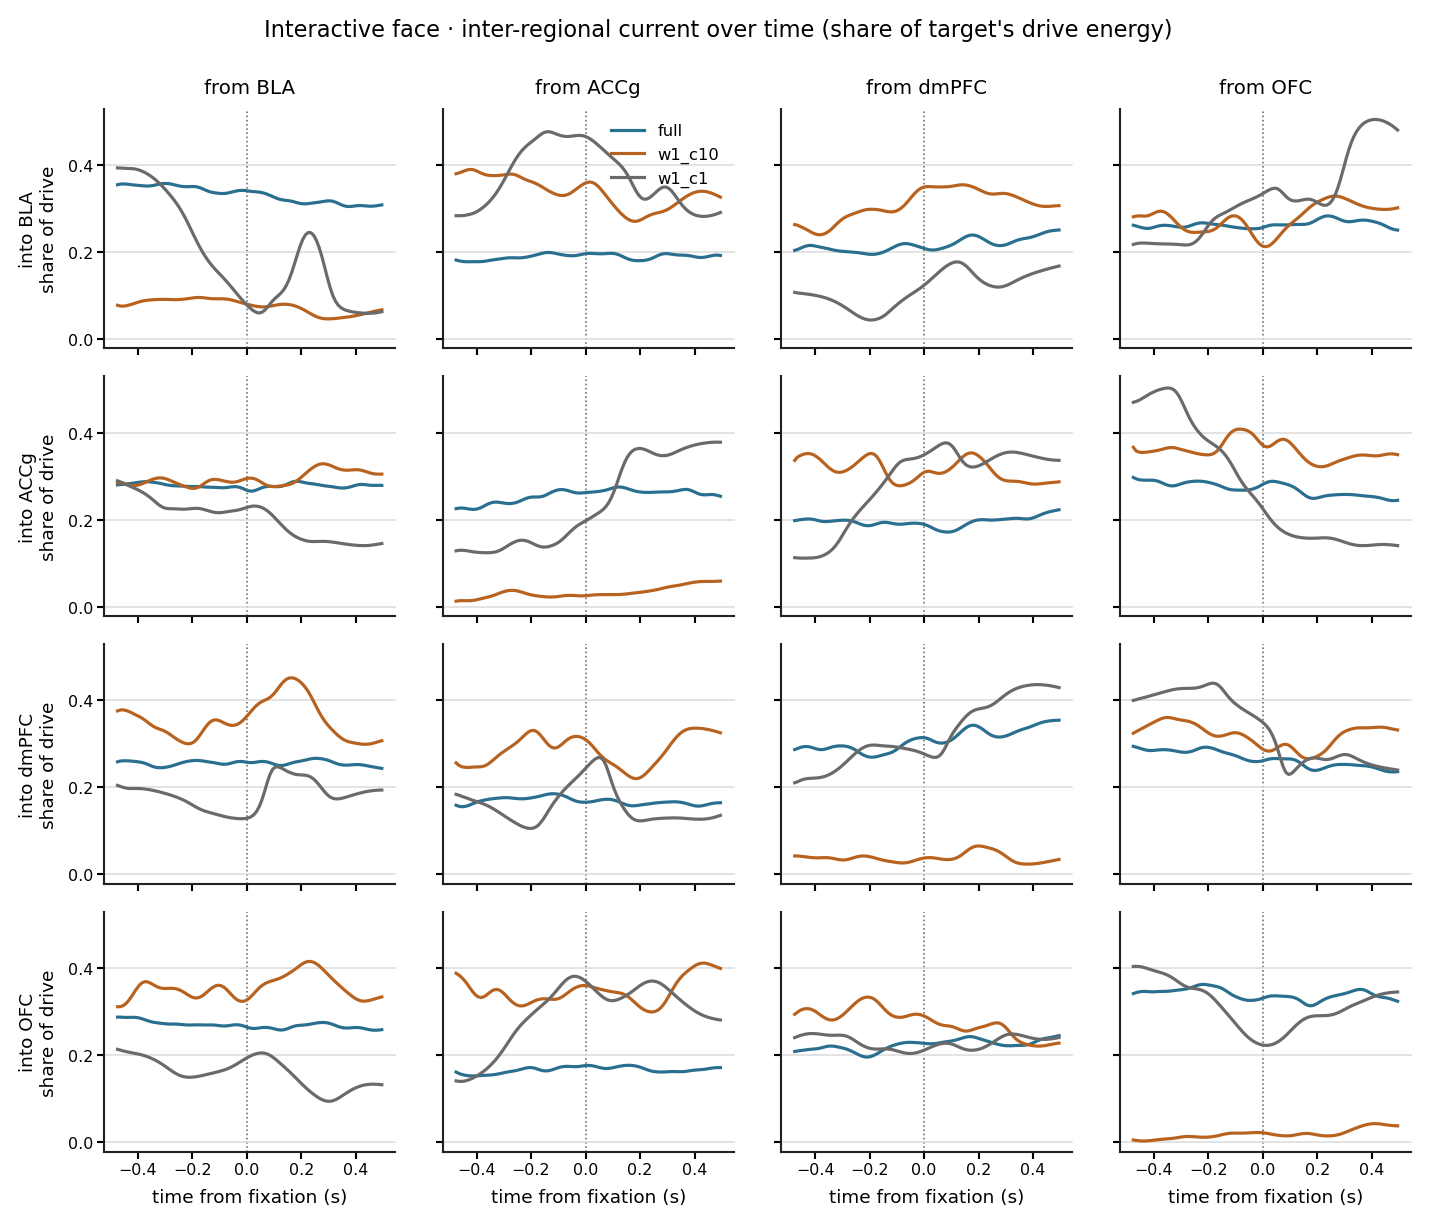

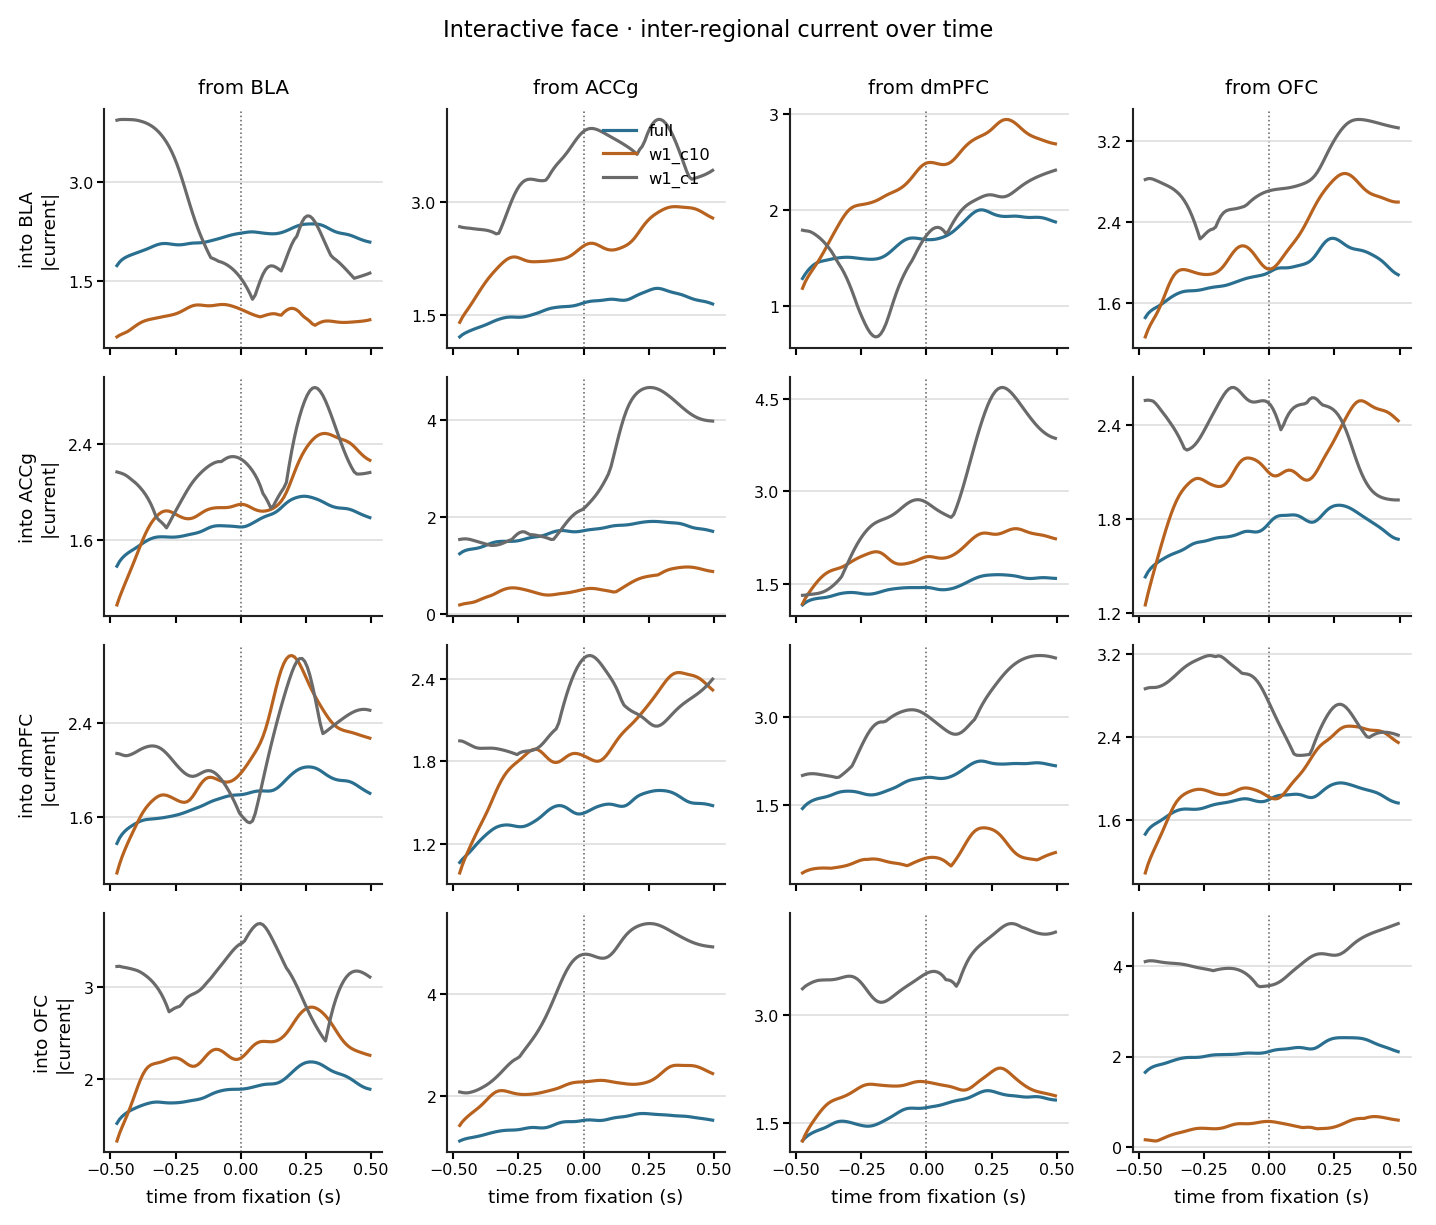

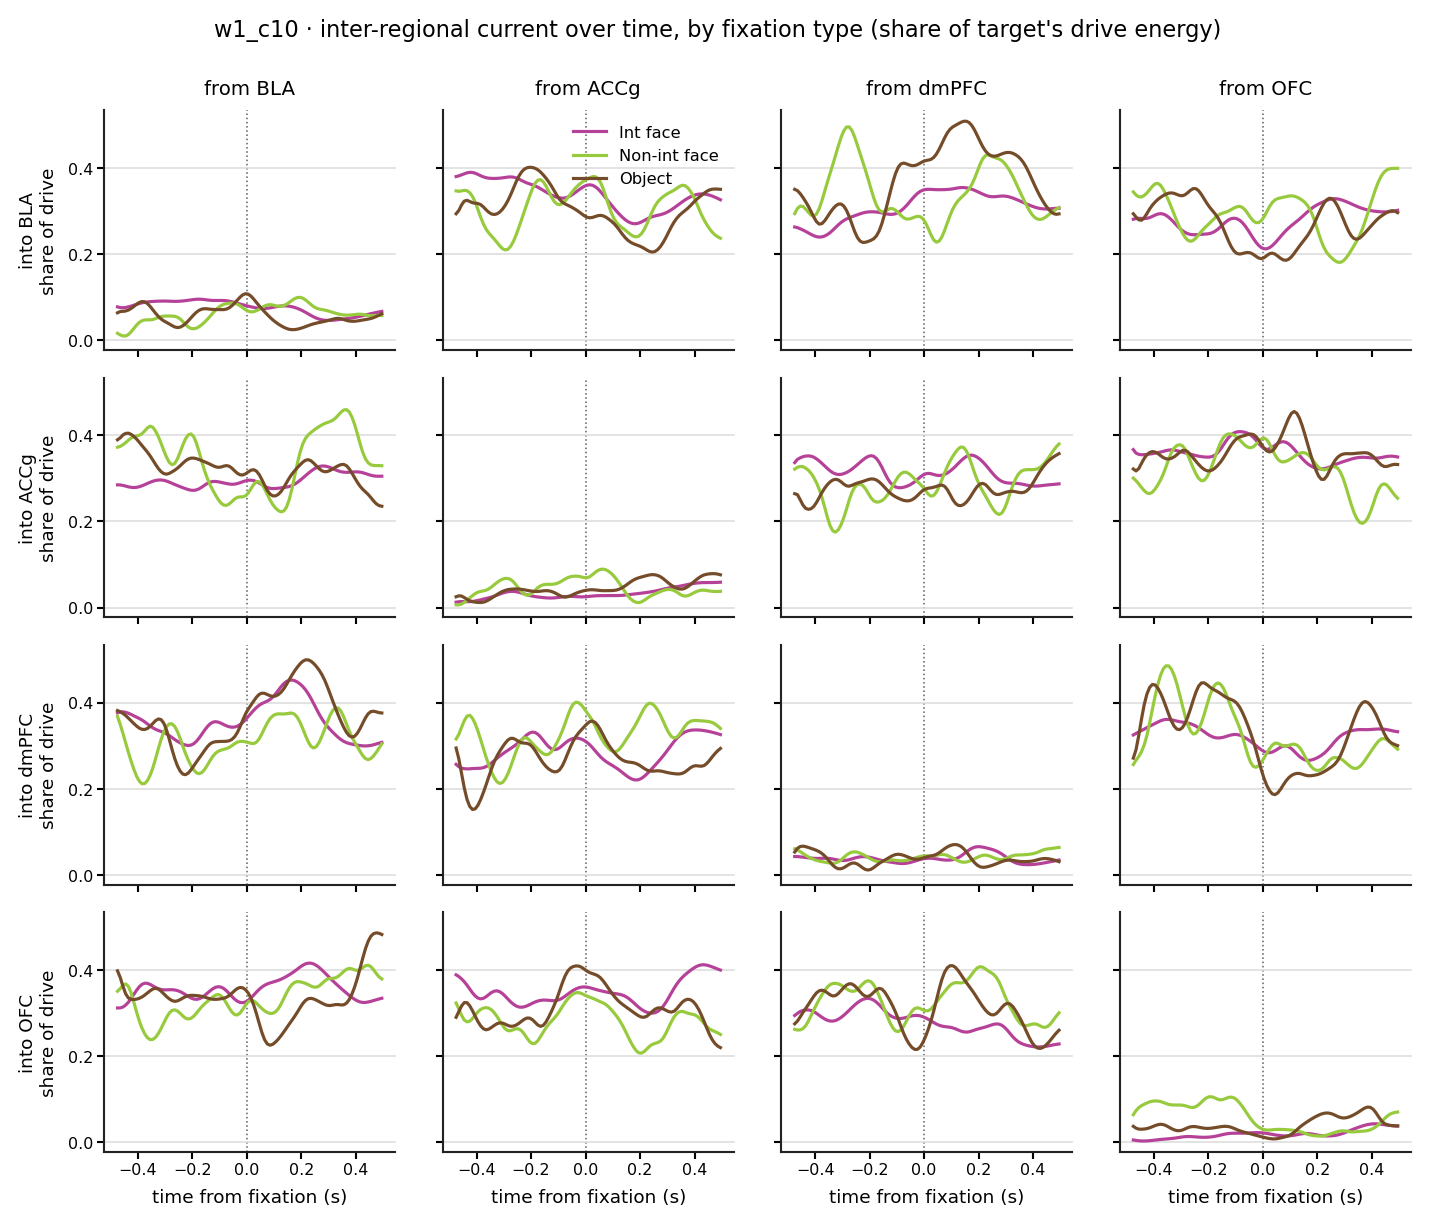

In [6]:
FLOW_CELLS = [c for c in ["full"] + [v.label for v in audit.rank_grid_variants(RANKS, base_overrides={}, include_marginals=True)
                                     if v.arm != "grid" or v.label in REFERENCE_CELLS] if c in ARMS]
flow = cached("time_resolved_flow",
              lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_flow))
show(aviz.plot_flow_matrix(flow, cells=REFERENCE_CELLS, condition="face_interactive", normalise="share"),
     "fig05a_flow_share_int_face")
show(aviz.plot_flow_matrix(flow, cells=REFERENCE_CELLS, condition="face_interactive"),
     "fig05b_flow_raw_int_face")
show(aviz.plot_flow_matrix(flow, cells=[SELECTED["label"]], normalise="share"),
     "fig05c_flow_share_by_condition_selected")

Two things to see. In the dense network the flow is smooth and nearly constant in time; the
constrained networks concentrate it into transients. And in the selected cell the diagonal —
each region's own recurrence — has almost vanished as a share of drive, so what looks like a
"region's activity" in that model is almost entirely what the other three are sending it.

## 6. Steady or bursty

The network's share of a region's drive energy over the trial, per fixation type (rows) and
region (columns), for the three reference cells. Then the within-trial **modulation** of that
share — its standard deviation over time — as a property along the cross marginal. A channel
too narrow to carry everything at once forces the region to alternate between driving itself
and being driven, and the alternation is the signature.

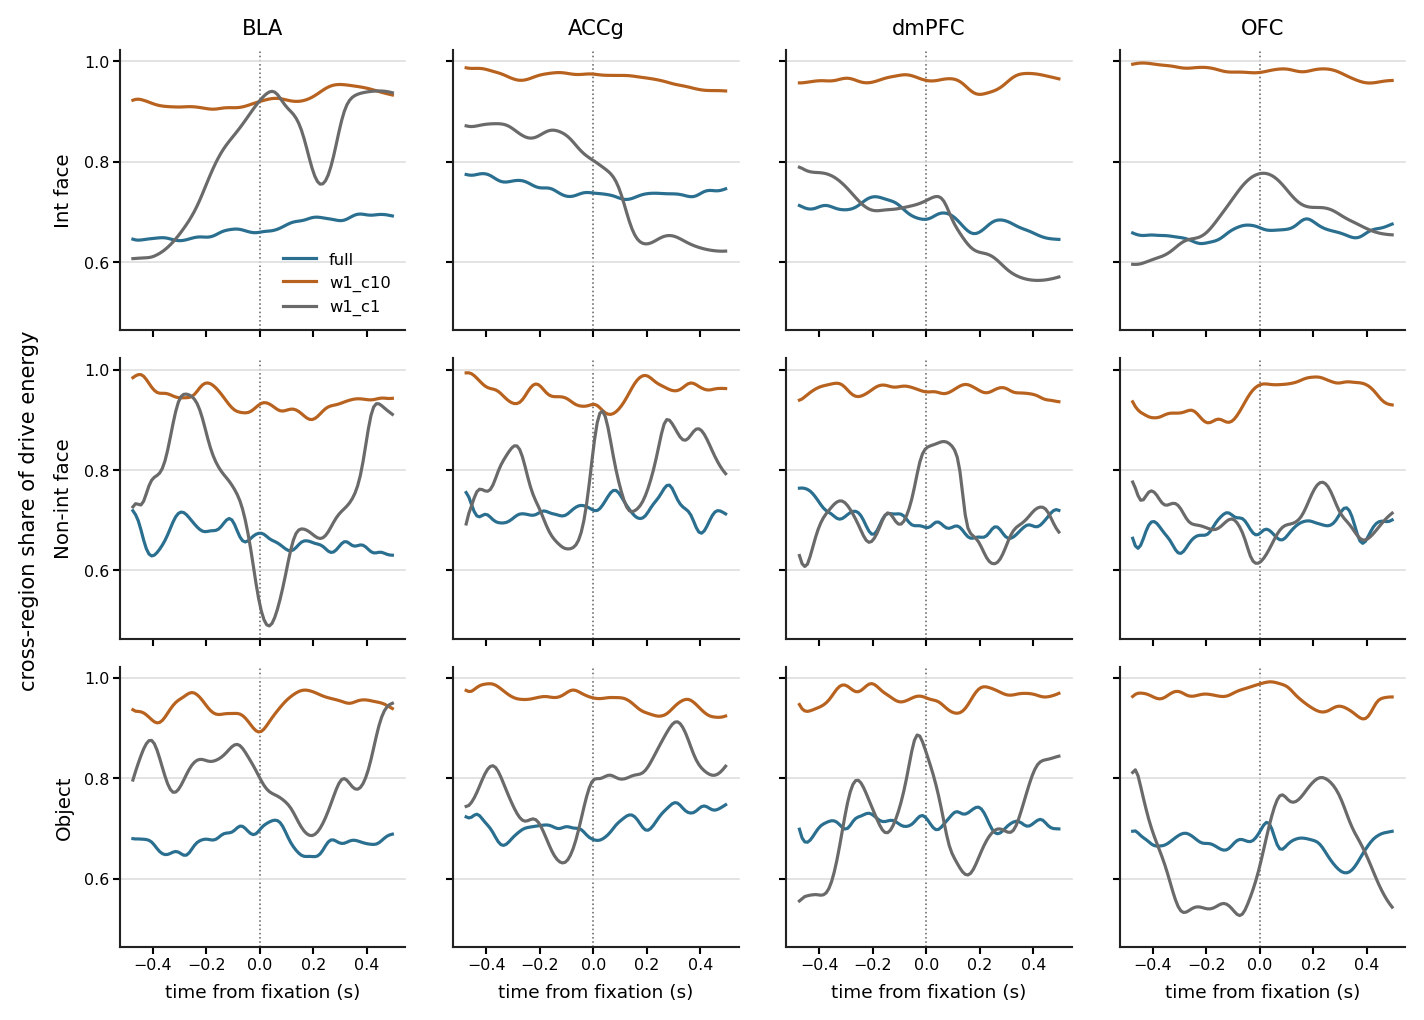

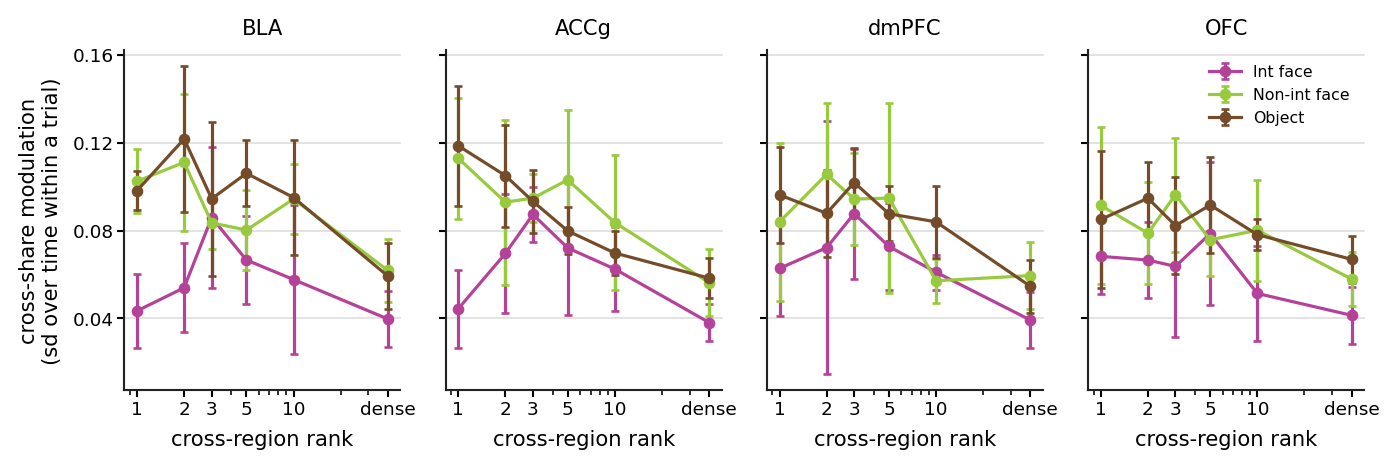

condition,face_interactive,face_non_interactive,object
label,,,
full,0.040,0.059,0.060
w1_c10,0.028,0.047,0.043
w1_c1,0.152,0.194,0.202


In [7]:
decomposed = audit.flow_decomposition(flow)
show(aviz.plot_flow_time_by_condition(decomposed, cells=REFERENCE_CELLS,
                                      ylabel="cross-region share of drive energy"),
     "fig06a_cross_share_over_time")
temporal = with_ranks(audit.flow_temporal_summary(decomposed))
temporal_within_dense = temporal[temporal["rank_within"] == HIDDEN_UNITS]
show(aviz.plot_property_vs_rank(temporal_within_dense, "cross_fraction_modulation", rank_column="rank_cross",
                                ylabel="cross-share modulation\n(sd over time within a trial)"),
     "fig06b_cross_share_modulation_vs_cross_rank")
display(temporal.groupby(["label", "condition"])["cross_fraction_modulation"].mean().unstack()
        .loc[REFERENCE_CELLS].round(3))

## 7. With or against

The cosine between the current a region receives from each partner and the region's own
recurrent drive, in time. Positive: the partner pushes the region the way its own dynamics
were already going. Task 06's drive-alignment invariant was the time-average of this; here it
is resolved, and shown along the cross marginal as a mean.

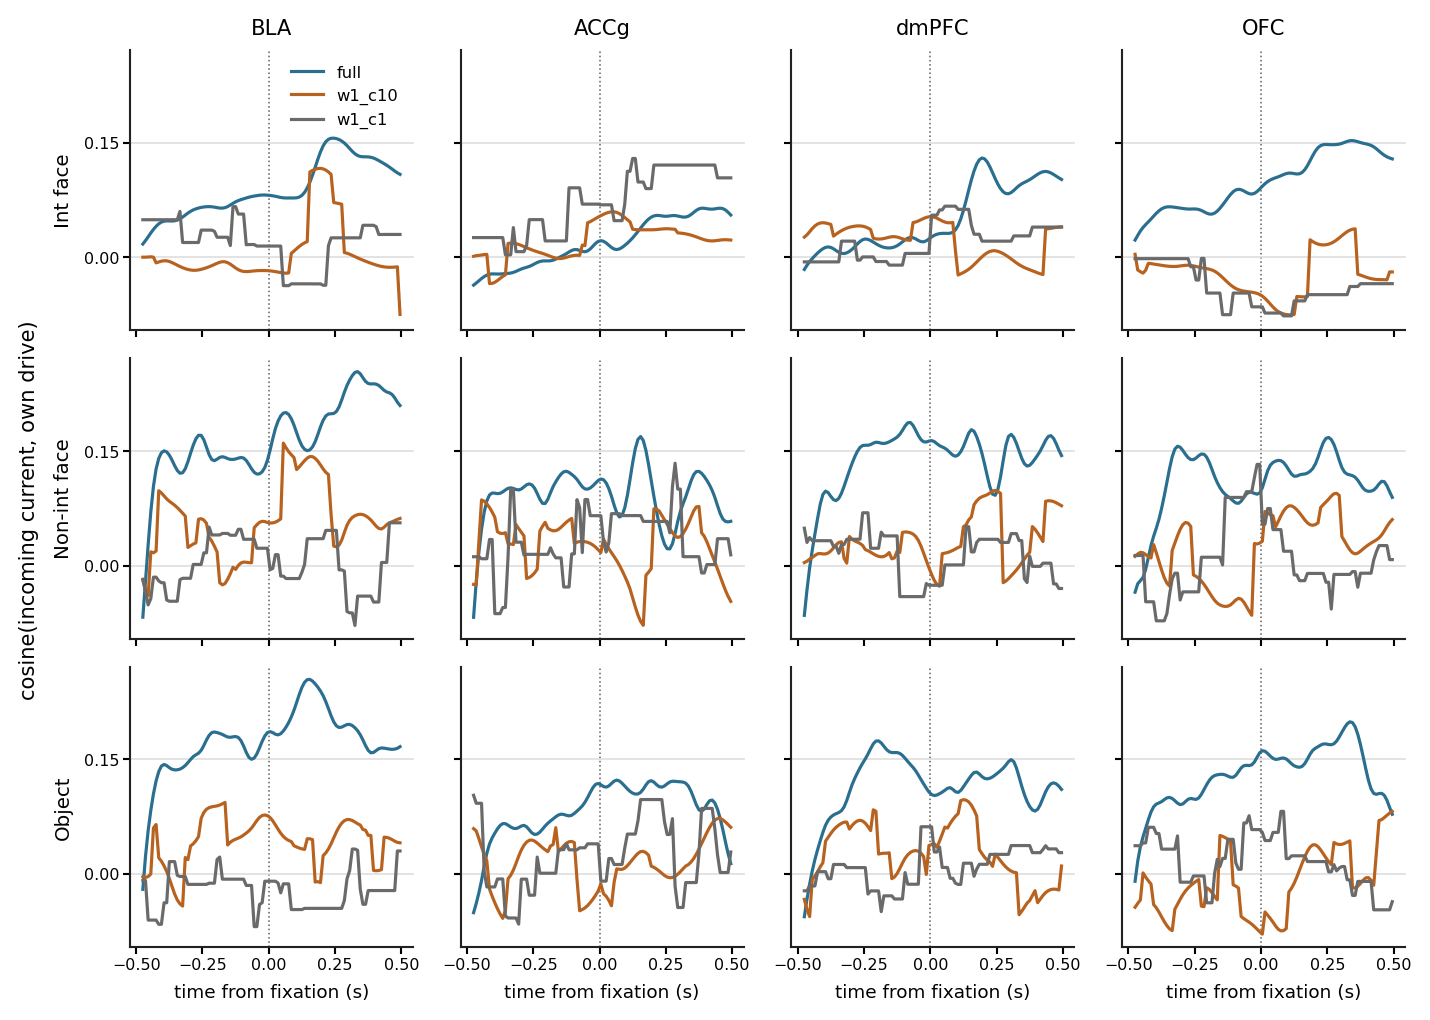

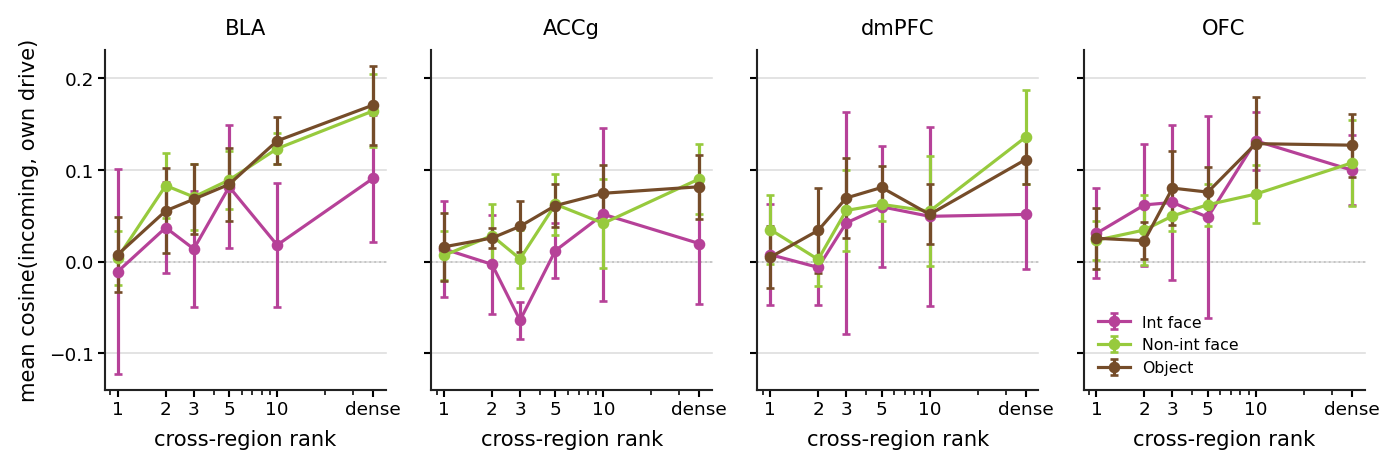

**Is interactive face the least-aligned condition?** In the dense network: 75% of (seed, region) cells, mean cosine 0.065 against 0.124 / 0.122. In `w1_c10`: 50%. In `w1_c1`: 30%.

condition,face_interactive,face_non_interactive,object
rank_cross,,,
1,0.014,0.016,0.010
2,0.022,0.037,0.034
3,0.014,0.045,0.064
5,0.050,0.069,0.075
10,0.035,0.054,0.057
40,0.034,0.058,0.058


In [8]:
alignment = cached("time_resolved_alignment",
                   lambda: audit.collect_over_arms({c: ARMS[c] for c in FLOW_CELLS}, audit.time_resolved_alignment))
align_by_target = (alignment.groupby(["label", "seed", "target", "condition", "time_s"])["cosine"].mean()
                   .reset_index())
show(aviz.plot_flow_time_by_condition(align_by_target, cells=REFERENCE_CELLS, value="cosine",
                                      ylabel="cosine(incoming current, own drive)"),
     "fig07a_alignment_over_time")
align_mean = with_ranks(alignment.groupby(["label", "seed", "target", "condition"])["cosine"].mean()
                        .reset_index().rename(columns={"target": "region"}))
show(aviz.plot_property_vs_rank(align_mean[align_mean["rank_within"] == HIDDEN_UNITS], "cosine",
                                rank_column="rank_cross", reference=0.0,
                                ylabel="mean cosine(incoming, own drive)"),
     "fig07b_alignment_vs_cross_rank")
fi_lowest = (align_mean.groupby(["label", "seed", "region", "condition"])["cosine"].mean().unstack("condition"))
fi_lowest["fi_lowest"] = fi_lowest.idxmin(axis=1) == "face_interactive"
per_cell = fi_lowest.groupby(level="label")["fi_lowest"].mean().loc[REFERENCE_CELLS]
dense_means = fi_lowest.loc["full", ["face_interactive", "face_non_interactive", "object"]].mean()
display(Markdown(
    "**Is interactive face the least-aligned condition?** In the dense network: "
    f"{per_cell['full']:.0%} of (seed, region) cells, mean cosine "
    f"{dense_means['face_interactive']:.3f} against {dense_means['face_non_interactive']:.3f} / "
    f"{dense_means['object']:.3f}. In `{SELECTED['label']}`: {per_cell[SELECTED['label']]:.0%}. "
    f"In `w1_c1`: {per_cell['w1_c1']:.0%}."))
display(align_mean.groupby(["rank_cross", "condition"])["cosine"].mean().unstack().round(3))

## 8. Reading the result

What the bottleneck changes, and what it does not:

- **Where the drive comes from.** Rank-1 self-recurrence hands the region over to the network
  (cross share 0.68 → 0.95) at no cost. A rank-1 channel hands it back to self-recurrence
  (cross share → 0.17) — and the fit degrades. The network reroutes freely in both directions;
  only one direction reproduces the data. Self-recurrence substitutes for the channel in
  energy, not in content.
- **How flow is arranged in time.** Dense: steady. Narrow: bursty. Below the bar, a region
  alternates within a trial between driving itself and being driven, and the timing of those
  alternations differs by fixation type.
- **Which fixation type the channel carries.** Interactive face is the worst-fitted condition
  in essentially every constrained fit, and its gap to the others widens as the channel
  narrows. It is the fixation type that most needs what the network sends.
- **With or against.** In the dense network the incoming current is mildly aligned with a
  region's own drive (cosine ~0.12), and about half as aligned for interactive face (~0.065,
  the lowest condition in three-quarters of seed × region cells — the audit's I3, at the mean
  but no longer universal per fit). Narrowing the channel drives every condition's alignment
  toward **zero**: the constrained network stops reinforcing local recurrence and sends
  directions orthogonal to it. That is why the condition ordering vanishes under constraint —
  there is nothing left to order.

**Next:** `03_ensemble.ipynb` refits the selected cell ten times and asks what those fits agree
on, against the ten-seed dense network.